# **1. Perkenalan Dataset**

## Indonesian Twitter Emotion Dataset

Dataset yang digunakan adalah **Indonesian Twitter Emotion Dataset**, yaitu kumpulan tweet berbahasa Indonesia yang telah dilabeli dengan kategori emosi.

### Sumber Dataset
- **Dataset 1 (EmoTweetID-Human)**: Dataset tweet emosi Indonesia dengan anotasi manual oleh manusia
- **Dataset 2 (Twitter Emotion Dataset)**: Dataset publik dari Kaggle ([link](https://www.kaggle.com/datasets/dennisherdi/indonesian-twitter-emotion))
- **Kamus Slang**: Kamus singkatan/slang bahasa Indonesia untuk normalisasi teks

### Deskripsi Dataset
Dataset ini digunakan untuk membangun sistem klasifikasi emosi pada platform konseling berbasis AI (**Myfess**). Model akan membantu mengidentifikasi kondisi emosional pengguna dari teks yang mereka tulis.

### Kategori Emosi
- **Anger** (Marah)
- **Fear** (Takut)
- **Happy** (Senang)
- **Love** (Cinta)
- **Sadness** (Sedih)
- **Surprise** (Kaget)

### Relevansi
Klasifikasi emosi dari teks sangat relevan untuk:
1. Aplikasi kesehatan mental dan konseling digital
2. Sistem deteksi dini kondisi psikologis pengguna
3. Personalisasi respons chatbot konseling

# **2. Import Library**

Mengimpor seluruh pustaka yang dibutuhkan untuk analisis data, preprocessing teks, dan persiapan pemodelan dengan IndoBERT.

In [1]:
# Install dependencies
!pip install -q transformers==4.41.2 accelerate==0.30.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 117.9 MB/s eta 0:00:00


In [2]:
# DATA MANIPULATION
import pandas as pd
import numpy as np
import json
import pickle
import re
import os

# VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# MACHINE LEARNING
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)

# KONFIGURASI VISUALISASI
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✓ Seluruh library berhasil dimuat")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")

✓ Seluruh library berhasil dimuat
  pandas  : 2.2.2
  numpy   : 2.0.2


# **3. Memuat Dataset**

Memuat dua dataset tweet emosi bahasa Indonesia dan kamus slang, kemudian menggabungkan keduanya menjadi satu dataset yang siap dianalisis.

> **Catatan**: Upload file dataset ke Colab terlebih dahulu melalui panel Files (icon folder di kiri), atau mount Google Drive.

In [3]:
# PATH DATASET
PATH_DATASET_1  = 'TwitterEmotion_raw/EmoTweetID-Human.csv'
PATH_DATASET_2  = 'TwitterEmotion_raw/Twitter_Emotion_Dataset.csv'
PATH_SLANG_DICT = 'TwitterEmotion_raw/kamus_singkatan.xlsx'

print("Path dataset sudah dikonfigurasi")
print(f"  Dataset 1  : {PATH_DATASET_1}")
print(f"  Dataset 2  : {PATH_DATASET_2}")
print(f"  Kamus Slang: {PATH_SLANG_DICT}")

Path dataset sudah dikonfigurasi
  Dataset 1  : TwitterEmotion_raw/EmoTweetID-Human.csv
  Dataset 2  : TwitterEmotion_raw/Twitter_Emotion_Dataset.csv
  Kamus Slang: TwitterEmotion_raw/kamus_singkatan.xlsx


In [4]:
# LOAD DATASET 1: EmoTweetID-Human
df1 = pd.read_csv(PATH_DATASET_1)
df1.columns = ['id', 'tweet', 'label']
df1 = df1[['tweet', 'label']]

# LOAD DATASET 2: Twitter Emotion Dataset
df2 = pd.read_csv(PATH_DATASET_2, sep=None, engine='python')
df2.columns = ['label', 'tweet']
df2 = df2[['tweet', 'label']]

print(f"✓ Dataset 1 dimuat: {len(df1):,} baris")
print(f"✓ Dataset 2 dimuat: {len(df2):,} baris")
print(f"\n--- 5 baris pertama Dataset 1 ---")
display(df1.head())
print(f"\n--- 5 baris pertama Dataset 2 ---")
display(df2.head())

✓ Dataset 1 dimuat: 2,243 baris
✓ Dataset 2 dimuat: 4,401 baris

--- 5 baris pertama Dataset 1 ---


,tweet,label
0,wah belom liat muka gue lagi murka hahahaha,joy
1,Mungkin kurang piknik adrenalin. Mereka yg ske...,anger
2,"maaf kalo tersinggung ""orang kurus cepet mati""...",anger
3,berserah pada maha esa paling tabah dan sabar ...,joy
4,Ehekk malu la hahahahahahaha,sadness



--- 5 baris pertama Dataset 2 ---


,tweet,label
0,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",anger
1,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",anger
2,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,happy
3,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...",anger
4,"Sharing pengalaman aja, kemarin jam 18.00 bata...",happy


In [5]:
# GABUNGKAN KEDUA DATASET
df = pd.concat([df1, df2], ignore_index=True)

# Hapus duplikat
df.drop_duplicates(subset=['tweet'], inplace=True)

# Standardisasi label
df['label'] = df['label'].str.strip().str.lower()
df.reset_index(drop=True, inplace=True)

print(f"✓ Total data setelah digabung : {len(df):,} baris")
print(f"✓ Missing values              : {df.isnull().sum().sum()}")
print(f"\nDistribusi Label:")
print(df['label'].value_counts())
print(f"\nInfo Dataset:")
df.info()

✓ Total data setelah digabung : 6,603 baris
✓ Missing values              : 0

Distribusi Label:
label
anger       1568
sadness     1296
fear        1035
happy       1012
love         636
joy          420
disgust      353
surprise     283
Name: count, dtype: int64

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6603 entries, 0 to 6602
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   6603 non-null   object
 1   label   6603 non-null   object
dtypes: object(2)
memory usage: 103.3+ KB


# **4. Exploratory Data Analysis (EDA)**

Memahami karakteristik dataset secara mendalam sebelum preprocessing.

/tmp/ipykernel_880/2563933958.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='viridis')


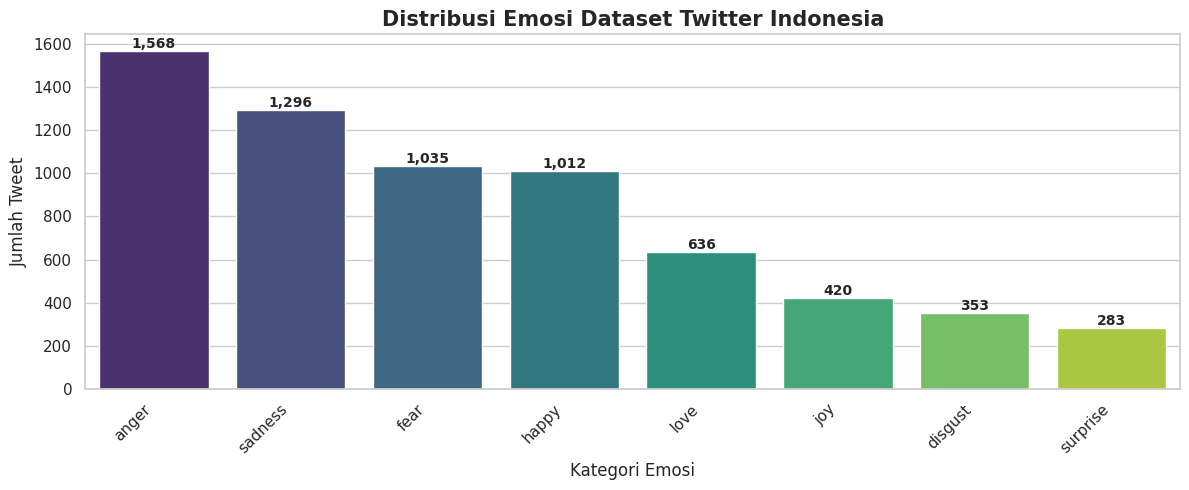

Total kategori : 8
Terbanyak      : anger (1,568)
Tersedikit     : surprise (283)
Rasio imbalance: 5.54x


In [6]:
# 4.1 DISTRIBUSI KELAS EMOSI
emotion_counts = df['label'].value_counts()

plt.figure(figsize=(12, 5))
ax = sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='viridis')
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height:,}',
                xy=(p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Distribusi Emosi Dataset Twitter Indonesia', fontsize=15, fontweight='bold')
plt.xlabel('Kategori Emosi')
plt.ylabel('Jumlah Tweet')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Total kategori : {len(emotion_counts)}")
print(f"Terbanyak      : {emotion_counts.index[0]} ({emotion_counts.iloc[0]:,})")
print(f"Tersedikit     : {emotion_counts.index[-1]} ({emotion_counts.iloc[-1]:,})")
print(f"Rasio imbalance: {emotion_counts.iloc[0]/emotion_counts.iloc[-1]:.2f}x")

Statistik Panjang Teks (Raw):
       raw_length  word_count
count     6603.00     6603.00
mean       155.71       24.89
std         74.02       11.94
min          5.00        1.00
25%        102.00       16.00
50%        158.00       25.00
75%        212.00       34.00
max        500.00       80.00


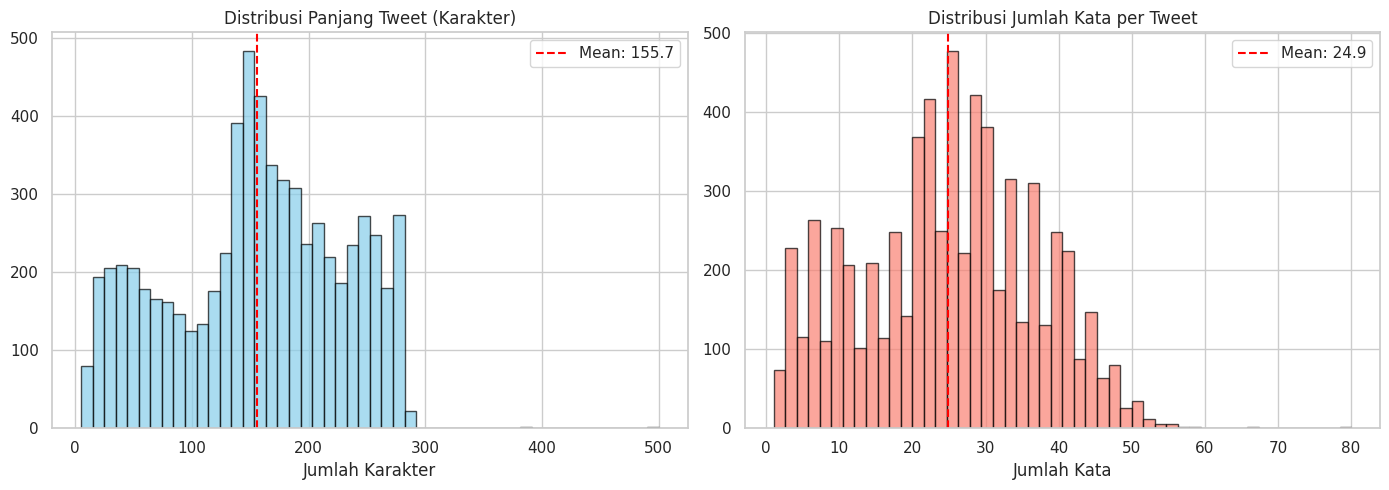

In [7]:
# 4.2 STATISTIK PANJANG TEKS
df['raw_length'] = df['tweet'].apply(len)
df['word_count'] = df['tweet'].apply(lambda x: len(str(x).split()))

print("Statistik Panjang Teks (Raw):")
print(df[['raw_length', 'word_count']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['raw_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['raw_length'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["raw_length"].mean():.1f}')
axes[0].set_title('Distribusi Panjang Tweet (Karakter)')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].legend()

axes[1].hist(df['word_count'], bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["word_count"].mean():.1f}')
axes[1].set_title('Distribusi Jumlah Kata per Tweet')
axes[1].set_xlabel('Jumlah Kata')
axes[1].legend()
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

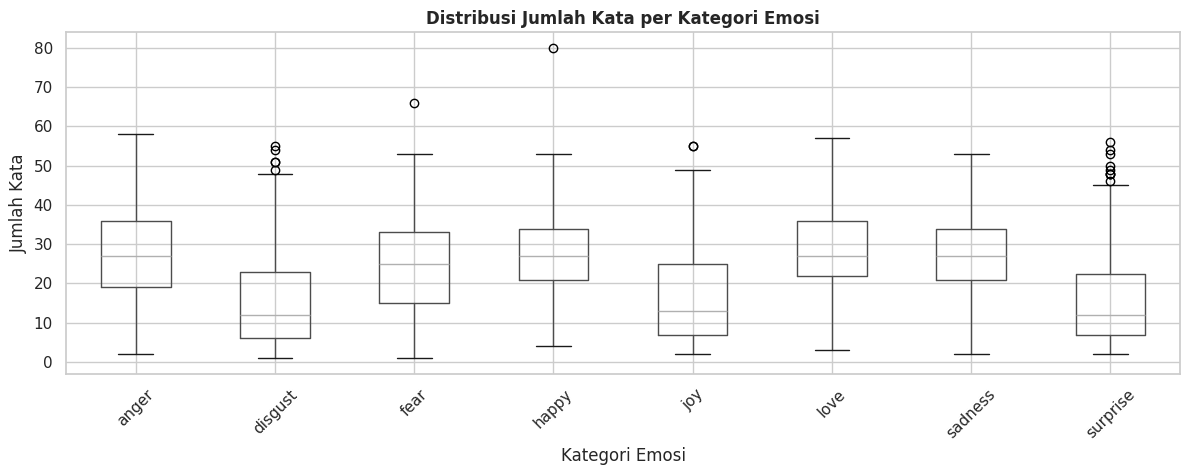

Rata-rata jumlah kata per kategori:
           mean  median    std
label                         
anger     26.53    27.0  11.96
disgust   15.57    12.0  12.21
fear      24.36    25.0  12.27
happy     27.38    27.0   9.43
joy       17.07    13.0  12.67
love      28.49    27.0   9.42
sadness   26.61    27.0  10.84
surprise  16.22    12.0  12.24


In [8]:
# 4.3 DISTRIBUSI PANJANG TEKS PER KATEGORI
plt.figure(figsize=(12, 5))
df.boxplot(column='word_count', by='label', figsize=(12, 5))
plt.title('Distribusi Jumlah Kata per Kategori Emosi', fontweight='bold')
plt.suptitle('')
plt.xlabel('Kategori Emosi')
plt.ylabel('Jumlah Kata')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Rata-rata jumlah kata per kategori:")
print(df.groupby('label')['word_count'].agg(['mean','median','std']).round(2))

In [9]:
# 4.4 ANALISIS MISSING VALUES & DUPLIKAT
print("=" * 50)
print("ANALISIS KUALITAS DATA")
print("=" * 50)
print(f"Missing values:")
print(df[['tweet','label']].isnull().sum())
print(f"\nDuplikat tweet: {df.duplicated(subset=['tweet']).sum()}")
print(f"\nSample data:")
display(df[['tweet','label']].sample(5, random_state=42))

ANALISIS KUALITAS DATA
Missing values:
tweet    0
label    0
dtype: int64

Duplikat tweet: 0

Sample data:


,tweet,label
1483,Jan gitu dong malu gue,sadness
4264,Wah kalo gt anda udh menormalisasi bentuk pele...,sadness
239,"Terakhir dpt tip kek gitu, malam tahun baru, d...",fear
3501,Inilah salah satu sebab kenapa aku mending ngg...,fear
3296,[USERNAME] Sejak dulu kala ga pernah minat dgn...,anger


ANALISIS NOISE DALAM TEKS
  URL       : 6 (0.1%)
  Mention   : 19 (0.3%)
  Hashtag   : 391 (5.9%)
  Emoji     : 0 (0.0%)
  Angka     : 1,827 (27.7%)


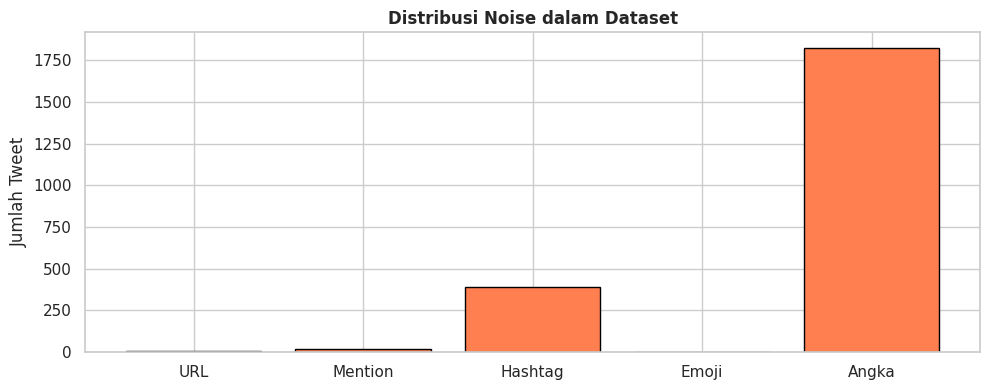

In [10]:
# 4.5 ANALISIS NOISE DALAM TEKS
has_url     = df['tweet'].str.contains(r'http\S+|www\S+', regex=True, na=False)
has_mention = df['tweet'].str.contains(r'@\w+', regex=True, na=False)
has_hashtag = df['tweet'].str.contains(r'#\w+', regex=True, na=False)
has_emoji   = df['tweet'].str.contains(r'[^\x00-\x7F]', regex=True, na=False)
has_number  = df['tweet'].str.contains(r'\d', regex=True, na=False)

noise_stats = {
    'URL'     : has_url.sum(),
    'Mention' : has_mention.sum(),
    'Hashtag' : has_hashtag.sum(),
    'Emoji'   : has_emoji.sum(),
    'Angka'   : has_number.sum(),
}

print("=" * 50)
print("ANALISIS NOISE DALAM TEKS")
print("=" * 50)
for k, v in noise_stats.items():
    print(f"  {k:<10}: {v:,} ({v/len(df)*100:.1f}%)")

plt.figure(figsize=(10, 4))
plt.bar(noise_stats.keys(), noise_stats.values(), color='coral', edgecolor='black')
plt.title('Distribusi Noise dalam Dataset', fontweight='bold')
plt.ylabel('Jumlah Tweet')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Membersihkan dan menormalisasi teks tweet sebelum digunakan untuk fine-tuning IndoBERT:
1. Lowercase
2. Hapus URL, mention, hashtag
3. Normalisasi karakter berulang
4. Hapus karakter non-alfabet
5. Normalisasi slang menggunakan kamus
6. Hapus kata tawa berlebihan
7. Label encoding & train-test split
8. Simpan hasil preprocessing

In [11]:
# 5.1 LOAD KAMUS SLANG
df_slang   = pd.read_excel(PATH_SLANG_DICT, header=None)
slang_dict = dict(zip(df_slang[0], df_slang[1]))

print(f"✓ Kamus slang dimuat: {len(slang_dict):,} entri")
print(f"\nContoh normalisasi:")
for w in ['gw', 'lu', 'yg', 'bgt', 'tp', 'krn']:
    print(f"  '{w}' → '{slang_dict.get(w, w)}'")

✓ Kamus slang dimuat: 1,243 entri

Contoh normalisasi:
  'gw' → 'saya'
  'lu' → 'kamu'
  'yg' → 'yang '
  'bgt' → 'sangat '
  'tp' → 'tapi'
  'krn' → 'karena '


In [12]:
# 5.2 FUNGSI PREPROCESSING
def preprocess_text(text):
    """
    Membersihkan dan menormalisasi teks tweet bahasa Indonesia.

    Args:
        text (str): Teks tweet mentah
    Returns:
        str: Teks yang sudah bersih
    """
    # Step 1: lowercase
    text = str(text).lower()
    # Step 2: Hapus URL, mention, hashtag
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#\w+', '', text)
    # Step 3: Normalisasi karakter berulang
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    # Step 4: Hapus karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Step 5: Normalisasi slang
    words = text.split()
    words = [slang_dict.get(word, word) for word in words]
    text  = ' '.join(words)
    # Step 6: Hapus kata tawa berlebihan
    text = re.sub(r'\b(wk|ha|he|hi|ho)+\b', '', text, flags=re.IGNORECASE)
    # Step 7: Bersihkan whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test fungsi
samples = [
    "Aku sediiihhhh bgttt 62d gara2 nilai jelek huhuhu",
    "@teman123 Wkwkwk jgn sedih yg semangat #motivasi",
    "https://example.com gw stress bgt sm tugas banyaaakkk"
]
print("Contoh Preprocessing:\n")
for i, t in enumerate(samples, 1):
    print(f"{i}. Original : {t}")
    print(f"   Cleaned  : {preprocess_text(t)}\n")

Contoh Preprocessing:

1. Original : Aku sediiihhhh bgttt 62d gara2 nilai jelek huhuhu
   Cleaned  : saya sediihh bgtt d gara nilai jelek huhuhu

2. Original : @teman123 Wkwkwk jgn sedih yg semangat #motivasi
   Cleaned  : jangan sedih yang semangat

3. Original : https://example.com gw stress bgt sm tugas banyaaakkk
   Cleaned  : saya stress sangat sama tugas banyaakk



In [13]:
# 5.3 TERAPKAN PREPROCESSING
df['clean_tweet'] = df['tweet'].apply(preprocess_text)

before = len(df)
df = df[df['clean_tweet'].str.strip() != '']
df.reset_index(drop=True, inplace=True)

print(f"✓ Preprocessing selesai")
print(f"  Data awal   : {before:,}")
print(f"  Data dihapus: {before - len(df):,} (teks kosong)")
print(f"  Data final  : {len(df):,}")
print(f"\nSample hasil preprocessing:")
display(df[['tweet','clean_tweet','label']].head(5))

✓ Preprocessing selesai
  Data awal   : 6,603
  Data dihapus: 0 (teks kosong)
  Data final  : 6,603

Sample hasil preprocessing:


,tweet,clean_tweet,label
0,wah belom liat muka gue lagi murka hahahaha,wah belum liat muka saya lagi murka,joy
1,Mungkin kurang piknik adrenalin. Mereka yg ske...,mungkin kurang piknik adrenalin mereka yang sk...,anger
2,"maaf kalo tersinggung ""orang kurus cepet mati""...",maaf kalau tersinggung orang kurus cepat mati ...,anger
3,berserah pada maha esa paling tabah dan sabar ...,berserah pada maha esa paling tabah dan sabar ...,joy
4,Ehekk malu la hahahahahahaha,ehekk malu la,sadness


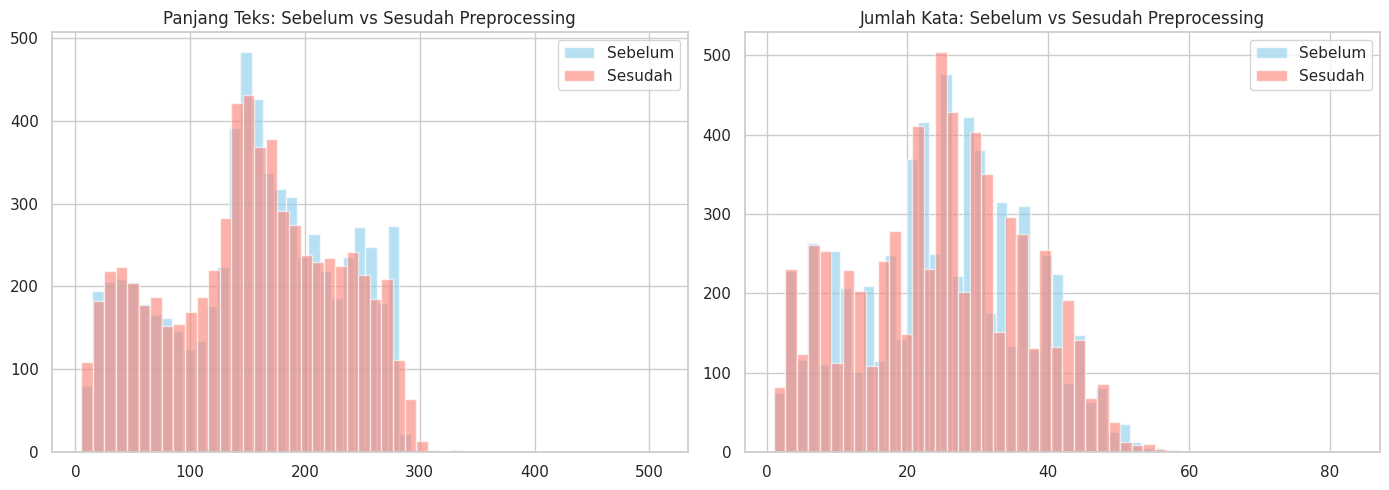

📊 95% data panjangnya ≤ 270 karakter → pakai max_length=128


In [14]:
# 5.4 ANALISIS PANJANG TEKS SETELAH PREPROCESSING
df['text_length']      = df['clean_tweet'].apply(len)
df['clean_word_count'] = df['clean_tweet'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['raw_length'],  bins=50, alpha=0.6, color='skyblue', label='Sebelum')
axes[0].hist(df['text_length'], bins=50, alpha=0.6, color='salmon',  label='Sesudah')
axes[0].set_title('Panjang Teks: Sebelum vs Sesudah Preprocessing')
axes[0].legend()

axes[1].hist(df['word_count'],       bins=50, alpha=0.6, color='skyblue', label='Sebelum')
axes[1].hist(df['clean_word_count'], bins=50, alpha=0.6, color='salmon',  label='Sesudah')
axes[1].set_title('Jumlah Kata: Sebelum vs Sesudah Preprocessing')
axes[1].legend()
plt.tight_layout()
plt.show()

p95 = np.percentile(df['text_length'], 95)
print(f"📊 95% data panjangnya ≤ {p95:.0f} karakter → pakai max_length=128")

In [15]:
# 5.5 LABEL ENCODING
df['label'] = df['label'].str.strip().str.lower()
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

label_mapping = {label: int(idx) for label, idx in
                 zip(le.classes_, le.transform(le.classes_))}
num_labels = len(le.classes_)

print(f"Jumlah kategori: {num_labels}")
for label, idx in sorted(label_mapping.items(), key=lambda x: x[1]):
    count = (df['label'] == label).sum()
    print(f"  {idx} → {label:<12} ({count:,} data)")

Jumlah kategori: 8
  0 → anger        (1,568 data)
  1 → disgust      (353 data)
  2 → fear         (1,035 data)
  3 → happy        (1,012 data)
  4 → joy          (420 data)
  5 → love         (636 data)
  6 → sadness      (1,296 data)
  7 → surprise     (283 data)


✓ Training   : 5,282 (80%)
✓ Validation : 1,321  (20%)


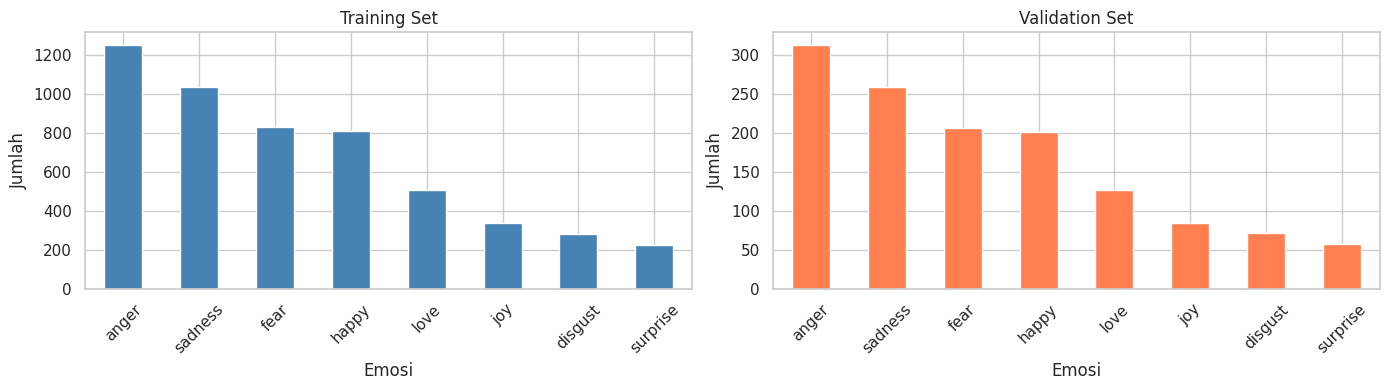

In [16]:
# 5.6 TRAIN-TEST SPLIT
df_train, df_val = train_test_split(
    df, test_size=0.2, random_state=RANDOM_SEED,
    stratify=df['label_id']
)
df_train.reset_index(drop=True, inplace=True);
df_val.reset_index(drop=True, inplace=True)

print(f"✓ Training   : {len(df_train):,} ({len(df_train)/len(df)*100:.0f}%)")
print(f"✓ Validation : {len(df_val):,}  ({len(df_val)/len(df)*100:.0f}%)")

# Visualisasi distribusi train vs val
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_train['label'].value_counts().plot(kind='bar', ax=axes[0],
    color='steelblue', title='Training Set')
df_val['label'].value_counts().plot(kind='bar', ax=axes[1],
    color='coral', title='Validation Set')
for ax in axes:
    ax.set_xlabel('Emosi')
    ax.set_ylabel('Jumlah')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# 5.7 SIMPAN HASIL PREPROCESSING
OUTPUT_DIR = 'twitter_emotion_preprocessing'
os.makedirs(OUTPUT_DIR, exist_ok=True)

cols = ['clean_tweet', 'label', 'label_id']
df_train[cols].to_csv(f'{OUTPUT_DIR}/train.csv', index=False)
df_val[cols].to_csv(  f'{OUTPUT_DIR}/val.csv',   index=False)
df[['tweet'] + cols].to_csv(f'{OUTPUT_DIR}/full.csv', index=False)

with open(f'{OUTPUT_DIR}/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

metadata = {
    'num_labels'    : num_labels,
    'label_mapping' : label_mapping,
    'total_samples' : len(df),
    'train_samples' : len(df_train),
    'val_samples'   : len(df_val),
    'max_length'    : 128
}
with open(f'{OUTPUT_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Hasil preprocessing disimpan di: {OUTPUT_DIR}/")
print(f"  train.csv        : {len(df_train):,} baris")
print(f"  val.csv          : {len(df_val):,} baris")
print(f"  full.csv         : {len(df):,} baris")
print(f"  label_encoder.pkl")
print(f"  metadata.json")
print(f"\n✅ Notebook selesai! Dataset siap untuk fine-tuning IndoBERT.")

✓ Hasil preprocessing disimpan di: twitter_emotion_preprocessing/
  train.csv        : 5,282 baris
  val.csv          : 1,321 baris
  full.csv         : 6,603 baris
  label_encoder.pkl
  metadata.json

✅ Notebook selesai! Dataset siap untuk fine-tuning IndoBERT.
